# Probabilistic population codes
__Author: [Florent Meyniel](https://florentmeyniel.weebly.com/), NeuroSpin (CEA Paris Saclay) and INM (GHU Paris Psychiatrie et neuroscience)__

[The Computational Brain Team](https://computationalbrainteam.com)

## The problem to solve: How does the brain infer the world state from neural activity?

In the class, we considered the following generative models:

world state (*s*) -> stimulus (*I*) -> neural response (*r*)

How does the brain infer (we can also say decode) the world state **s** from the stimulus **r**?

This problem is illustrated in the following figure (where they conflate the world state *s* and stimulus *I*)


<img src="https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fnn1790/MediaObjects/41593_2006_Article_BFnn1790_Fig1_HTML.jpg?as=webp" width="400">

This notebook presents the solution introduced by Ma, Pouget and collaborators ([Ma, Wei Ji, Jeffrey M. Beck, Peter E. Latham, and Alexandre Pouget. 2006. “Bayesian Inference with Probabilistic Population Codes.” Nature Neuroscience 9 (11): 1432–38. https://doi.org/10.1038/nn1790.
](https://www.nature.com/articles/nn1790))

## Initialize notebook

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import copy

In [ ]:
def generate_gaussian_tuning_curves(n, lower_val=0, upper_val=1, baseline=0):
    """ Generate a quasi translation invariant, set of bell-shaped tuning curves"""
    sigma=(upper_val - lower_val)/n
    centers = np.linspace(lower_val, upper_val, n+2)
    centers = centers[1:-1]
    return [lambda x, m=center, sigma=sigma, b=baseline: b + norm.pdf(x, loc=m, scale=sigma)
           for center in centers]

def generate_kernel_basis_set(n, gain=1, lower_val=0, upper_val=1, baseline=0.1):
    """ Create a basis set of kernels corresponding to bell-shaped tuning curves.
    The kernel is the log of the tuning curve in Probabilistic Population Codes."""
    sigma=0.1*(upper_val - lower_val)/n
    centers = np.linspace(lower_val, upper_val, n+2)
    centers = centers[1:-1]
    return [lambda x, m=center, g=gain, sigma=sigma, b=baseline: np.log(g*(np.exp(-(x-m)**2 / (2*sigma)) + b))
           for center in centers]

def compute_posterior_distribution(tuning_functions, r, val_grid):
    """ This inference is correct when the population follows a linear Probabilistic Population code
    with Poisson variability."""
    posterior = np.array(
            [np.exp(np.dot([np.log(tuning_function(stim)) for tuning_function in tuning_functions], r))
             for stim in val_grid])
    return posterior / np.sum(posterior)

def sample_activity_vector(tuning_functions, stimulus, gain=1, window_size=1):
    """ Sample activity assuming Poisson variability."""
    return np.mean(np.stack([[np.random.poisson(lam=gain*tuning_function(stimulus))
             for tuning_function in tuning_functions]
                            for _ in range(window_size)]),
                  axis=0)

In [3]:
np.random.seed(3)

## Simple case of PPC

We consider a population of $N$ neurons that produces an activity vector $r$ on a given trial when presented with some stimulus $s$. 

Each neuron $i$ has a mean number of spikes per unit time for a given stimulus described by its tuning curve, $f_i(s)$. The generative process of neural activity correspond to an independent Poisson process: 

$P(r_i = k) = \frac{f_i(s)^k}{k!} e^{-f_i(s)}$

With a few assumptions typically made regarding PPC, the likelihood function of the stimulus based on population activity can be re-written as:

$p(\mathbf{r} \mid s, g) = \phi_k(\mathbf{r}, g) \exp\left( \mathbf{h}^\mathrm{T}(s) \mathbf{r} \right)$

Where:
- $\phi_k(\mathbf{r}, g)$ is a scaling function, that depends on the gain $g$ of population activity, and population activity. It can be treated as a constant of no interest in the inference.
- $\mathbf{h}$ is a set of kernels related to the tuning curve through $\mathbf{h}=log(\mathbf{f})$

This section illustrates how to decode the stimulus $s$ from population activity on some trial $r$, assuming a flat prior.


In [4]:
# Number of neurons in the population
N = 8

# Gain of the population
gain = 10

# stimulus
stimulus = 0.5

# grid that is used to compute and plot probability distributions
s_grid = np.linspace(0, 1, 100)

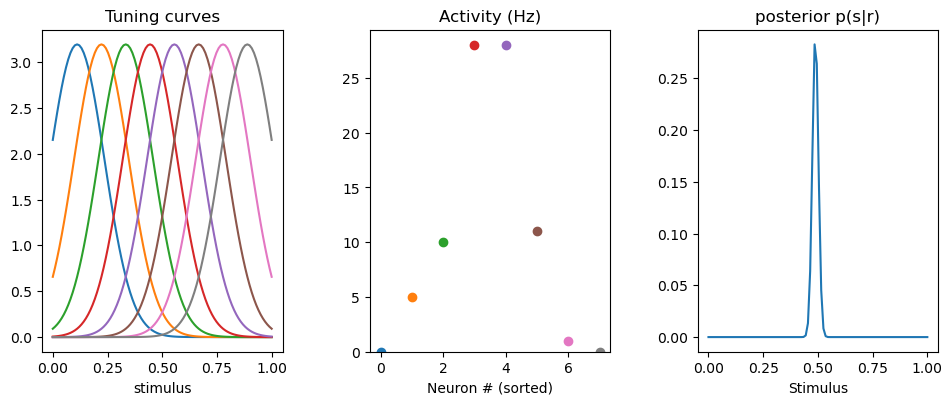

In [5]:
# generate the tuning functions
tuning_functions = generate_gaussian_tuning_curves(N)

# plot tuning curves
plt.subplot(1, 3, 1)
for tuning_function in tuning_functions:
    plt.plot(s_grid, tuning_function(s_grid))
plt.title('Tuning curves')
plt.xlabel('stimulus')

# generate a vector of activity
r = sample_activity_vector(tuning_functions, stimulus, gain)
plt.subplot(1, 3, 2)
for (idx, r_val) in enumerate(r):
    plt.plot(idx, r_val, 'o')
plt.ylim(bottom=0)
plt.xlabel('Neuron # (sorted)')
plt.title('Activity (Hz)')

# compute posterior inference
plt.subplot(1, 3, 3)
plt.plot(s_grid, compute_posterior_distribution(tuning_functions, r, s_grid))
plt.title('posterior p(s|r)')
plt.xlabel('Stimulus')
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(10, 4)
fig.savefig('PPC_simple_decoding.svg')

## A probabilistic population code provides a simple way to implement cue combination
### simple case: neural populations are aligned

In the simple case, there exists a correspondence, neuron-by-neuron, between the three populations, such that they have the same tuning curves across populations. In this case, **cue combination, i.e. the multiplication of the two probability distributions, corresponds to the element-wise sum of the two vectors of population activity.**

In [6]:
# Number of neurons in the population
N = 10

# Gain of the population
gain = 1

# stimulus
stimulus = 0.5

# grid that is used to compute and plot probability distributions
s_grid = np.linspace(0, 1, 100)

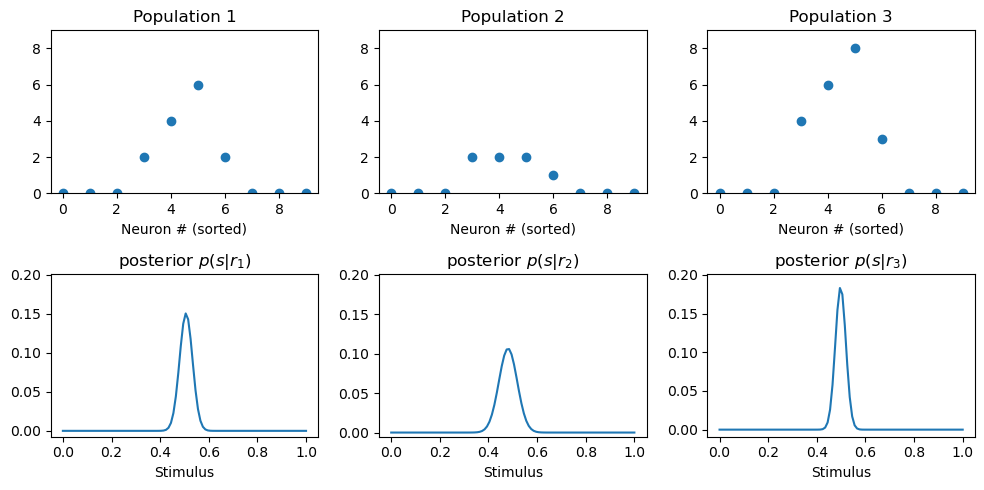

In [7]:
# generate the tuning functions
tuning_functions = generate_gaussian_tuning_curves(N)

# create activity vectors in two separate modalities
r = []
r.append(sample_activity_vector(tuning_functions, stimulus, gain))
r.append(sample_activity_vector(tuning_functions, stimulus, gain))

# compute activity vector in a third layer, as the sum of the two other layers
r.append(r[0] + r[1])

p_max = np.max([np.max(compute_posterior_distribution(tuning_functions, r_val, s_grid))
                for r_val in r])

for (idx, layer) in enumerate(r):
    plt.subplot(2, 3, idx+1)
    plt.plot(list(range(N)), r[idx], 'o')
    plt.ylim(bottom=0, top=np.max([np.max(val) for val in r])+1)
    plt.xlabel('Neuron # (sorted)')
    plt.title('Activity (Hz)')
    plt.ylim(bottom=0)
    plt.title(f"Population {idx+1}")
    
    plt.subplot(2, 3, 3 + idx + 1)
    plt.plot(s_grid, compute_posterior_distribution(tuning_functions, r[idx], s_grid))
    plt.ylim(top=p_max*1.1)
    plt.title(rf'$\mathrm{{posterior}}\ p(s|r_{{{idx+1}}})$')
    plt.xlabel('Stimulus')
fig = plt.gcf()
fig.set_size_inches(10, 5)
plt.tight_layout()
fig.savefig('PPC_aligned_cue_combination.svg')

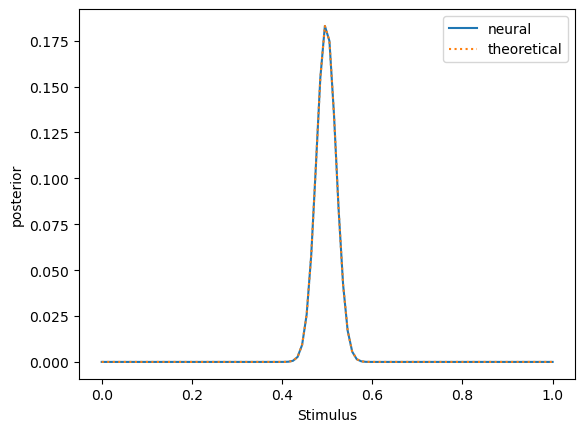

In [8]:
# compare the decoded posterior and the posterior theoretically computed
theoretical_posterior = (
    compute_posterior_distribution(tuning_functions, r[0], s_grid) *
    compute_posterior_distribution(tuning_functions, r[1], s_grid))
theoretical_posterior = theoretical_posterior / np.sum(theoretical_posterior)

plt.plot(s_grid, compute_posterior_distribution(tuning_functions, r[2], s_grid), label='neural')
plt.plot(s_grid, theoretical_posterior, ":", label='theoretical')
plt.ylabel('posterior')
plt.xlabel('Stimulus')
plt.legend()

### More complex case: neural populations are *not* aligned

In general, it is not reasonable to assume a neuron-by-neuron correspondence between populations during cue combination. A simple deviation is when the populations have different sizes. It is still possible to obtain the product of the probability distributions simply as a linear combination of the populations activity when the tuning curves in the different populations can be approximated by the same basis set of kernels.

In [ ]:
# define tuning curves in populations that are not aligned
N = [6, 12, 10]

# grid that is used to compute and plot probability distributions
s_grid = np.linspace(0, 1, 100)

# generate a basis set of kernels
kernel_basis_set = generate_kernel_basis_set(N[2], baseline=1)

# projection_matrices
projections = [np.random.randn(n, N[2]) for n in N[0:2]]
projections.append(np.eye(N[2]))

# compute tuning curves
multi_population_tuning_curves = []
for projection in projections:
    single_population_tuning_curves = []
    for single_neuron_proj in projection:
        fun = (lambda x, weights=single_neuron_proj: 
               # in PPC, the kernel is the log of the tuning curve.
               np.exp(sum(c * h(x) for c, h in zip(weights, kernel_basis_set))))
        single_population_tuning_curves.append(copy.deepcopy(fun))
    multi_population_tuning_curves.append(single_population_tuning_curves)

s_grid = np.linspace(0, 1, 100)
for idx in range(len(N)):
    plt.subplot(1, 3, idx+1)
    for tuning_function in multi_population_tuning_curves[idx]:
        plt.plot(s_grid, tuning_function(s_grid))
    plt.title(f'Tuning curves \n population {idx+1}')
    plt.xlabel('stimulus')
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(10, 3)

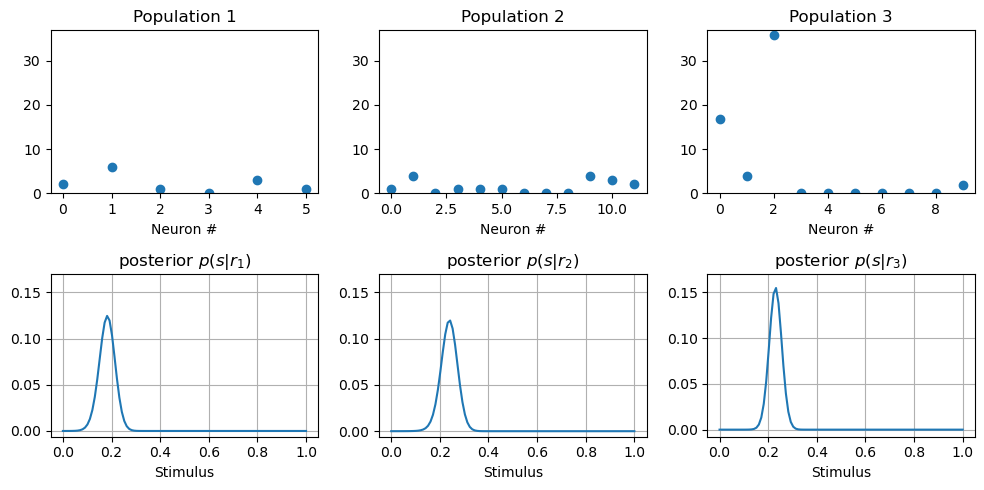

In [10]:
# choose generative stimulus value
stimulus = 0.3

# create activity vectors in two separate modalities
r = []
r.append(sample_activity_vector(multi_population_tuning_curves[0], stimulus, gain)[:, np.newaxis])
r.append(sample_activity_vector(multi_population_tuning_curves[1], stimulus, gain)[:, np.newaxis])

# compute activity vector in a third layer, as the sum of the two other layers
r.append(np.clip(projections[0].transpose()@r[0] + projections[1].transpose()@r[1],
                0, None))

p_max = np.max([np.max(compute_posterior_distribution(tuning_functions, r_val, s_grid))
                for (r_val, tuning_functions) in zip(r, multi_population_tuning_curves)])

for (idx, layer) in enumerate(r):
    plt.subplot(2, 3, idx+1)
    plt.plot(list(range(N[idx])), r[idx], 'o')
    plt.ylim(bottom=0, top=np.max([np.max(val) for val in r])+1)
    plt.xlabel('Neuron #')
    plt.title('Activity (Hz)')
    plt.ylim(bottom=0)
    plt.title(f"Population {idx+1}")

    plt.subplot(2, 3, 3 + idx + 1)
    plt.plot(s_grid, compute_posterior_distribution(multi_population_tuning_curves[idx], r[idx], s_grid))
    plt.ylim(top=p_max*1.1)
    plt.grid('on')
    plt.title(rf'$\mathrm{{posterior}}\ p(s|r_{{{idx+1}}})$')
    plt.xlabel('Stimulus')
fig = plt.gcf()
fig.set_size_inches(10, 5)
plt.tight_layout()

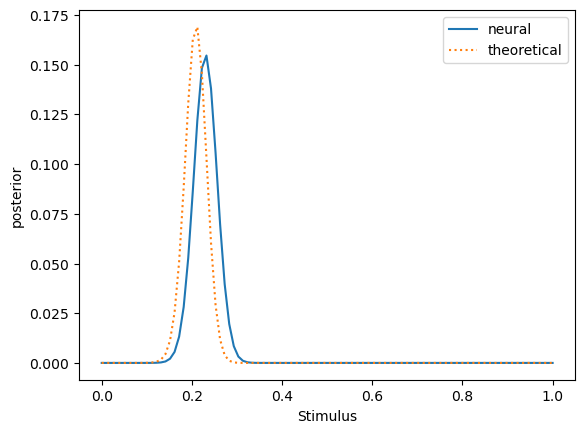

In [11]:
# compare the decoded posterior and the posterior theoretically computed
theoretical_posterior = (
    compute_posterior_distribution(multi_population_tuning_curves[0], r[0], s_grid) *
    compute_posterior_distribution(multi_population_tuning_curves[1], r[1], s_grid))
theoretical_posterior = theoretical_posterior / np.sum(theoretical_posterior)

plt.plot(s_grid, compute_posterior_distribution(multi_population_tuning_curves[2], r[2], s_grid), label='neural')
plt.plot(s_grid, theoretical_posterior, ":", label='theoretical')
plt.ylabel('posterior')
plt.xlabel('Stimulus')
plt.legend()